## Imports:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import altair as alt
from scripts.utilities import *
from scripts.features import *
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

## Reading in data:

In [ ]:
consumers, accounts, transactions = get_data()
transactions.amount = transactions.amount.apply(abs)

## Preprocesssing:

In [3]:
consumers.evaluation_date = pd.to_datetime(consumers.evaluation_date)
accounts.balance_date = pd.to_datetime(accounts.balance_date)
transactions.posted_date = pd.to_datetime(transactions.posted_date)

In [4]:
consumers.prism_consumer_id = consumers.prism_consumer_id.astype(int)
accounts.prism_consumer_id = accounts.prism_consumer_id.astype(int)
transactions.prism_consumer_id = transactions.prism_consumer_id.astype(int)

In [5]:
accounts.prism_account_id = accounts.prism_account_id.astype(int)

In [6]:
transactions.amount = transactions.amount.apply(abs)

## EDA:

In [7]:
c_df = consumers.dropna(subset='DQ_TARGET')
a_df = accounts[accounts.prism_consumer_id.isin(c_df.prism_consumer_id)]
t_df = transactions[transactions.prism_consumer_id.isin(c_df.prism_consumer_id)]
t_df = t_df.merge(categories, left_on='category', right_on='category_id')
t_df = t_df.drop(columns=['prism_transaction_id', 'category_x', 'category_id'])
t_df = t_df.rename(columns={'category_y':'category'})

display(c_df, a_df, t_df)

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
13995,13995,2022-01-22,802.0,0.0
13996,13996,2022-02-01,652.0,0.0
13997,13997,2021-12-24,765.0,0.0
13998,13998,2022-01-30,685.0,0.0


,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
5,3920,5,SAVINGS,2021-10-31,0.26
6,3920,6,CHECKING,2021-10-31,4.42
7,3920,7,CHECKING,2021-10-31,1.05
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


,prism_consumer_id,amount,credit_or_debit,posted_date,category
0,3023,0.05,CREDIT,2021-04-16,MISCELLANEOUS
1,3023,0.05,CREDIT,2021-05-16,MISCELLANEOUS
2,3023,0.07,CREDIT,2021-06-16,MISCELLANEOUS
3,3023,0.06,CREDIT,2021-07-16,MISCELLANEOUS
4,3023,0.07,CREDIT,2021-08-16,MISCELLANEOUS
...,...,...,...,...,...
5136829,13439,0.05,CREDIT,2022-01-31,INVESTMENT_INCOME
5136830,13439,0.04,CREDIT,2022-02-28,INVESTMENT_INCOME
5136831,13439,0.64,CREDIT,2021-12-31,INVESTMENT_INCOME
5136832,13439,1.30,CREDIT,2022-01-31,INVESTMENT_INCOME


## Account:

In [8]:
a_df.account_type.unique()

array(['SAVINGS', 'CHECKING', 'CREDIT CARD', 'LINE OF CREDIT', 'LOAN',
       'MONEY MARKET', 'ROTH', 'MORTGAGE', 'RETIREMENT', 'PREPAID',
       'BROKERAGE', 'CONSUMER', 'AUTO', 'IRA', 'CD', 'HSA',
       'CASH MANAGEMENT', 'OTHER', 'STUDENT', '401K', 'STOCK PLAN',
       'OVERDRAFT', 'HOME EQUITY'], dtype=object)

## DQ_TARGET Analysis:

- Sample of the goods and bads:

In [9]:
good = c_df[c_df.DQ_TARGET == 0] 
bad  = c_df[c_df.DQ_TARGET == 1] 

good_sample = good['prism_consumer_id'].sample(n=3, random_state=420)
bad_sample  = bad['prism_consumer_id'].sample(n=3, random_state=420)

- Looking at total balances per consumer and seeing the distribution:

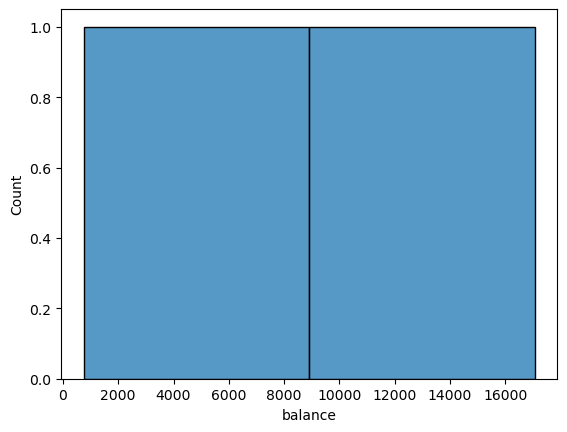

In [10]:
good_balances = a_df[a_df.prism_consumer_id.isin(good_sample)]
# good_balances.sort_values(['prism_consumer_id', 'prism_account_id', 'account_type', 'balance_date'])
sns.histplot(good_balances.groupby('prism_consumer_id')['balance'].sum());

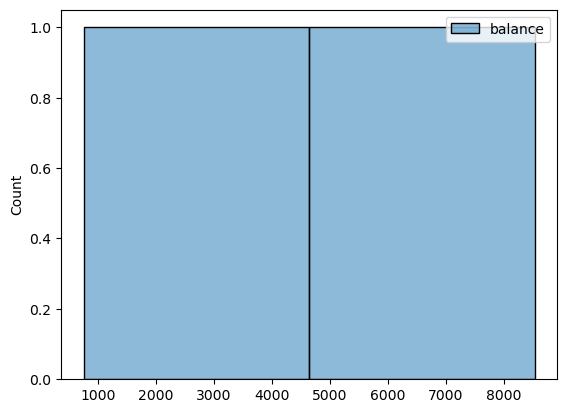

In [11]:
good_dist = good_balances.groupby('prism_consumer_id')[['balance']].mean()
sns.histplot(good_dist);

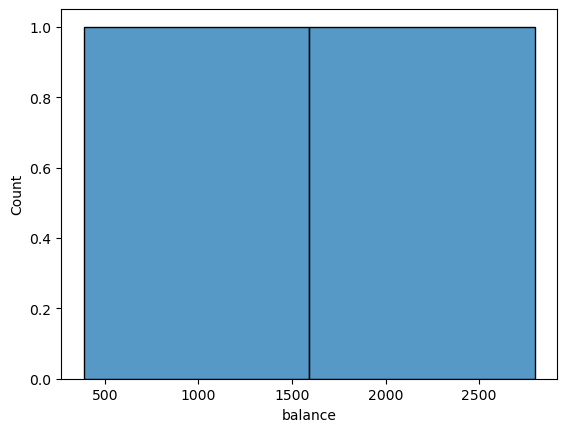

In [12]:
bad_balances = a_df[a_df.prism_consumer_id.isin(bad_sample)]
# bad_balances.sort_values(['prism_consumer_id', 'prism_account_id', 'account_type', 'balance_date'])
sns.histplot(bad_balances.groupby('prism_consumer_id')['balance'].sum());

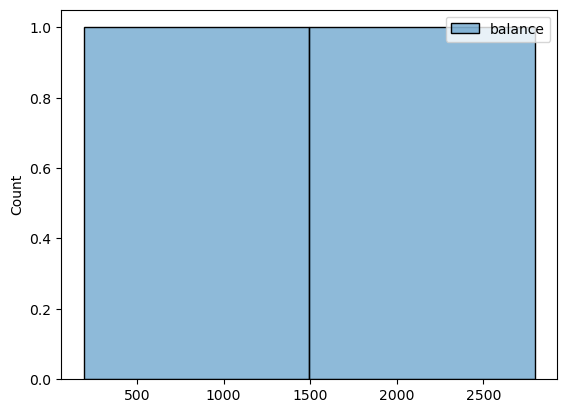

In [13]:
bad_dist = bad_balances.groupby('prism_consumer_id')[['balance']].mean()
sns.histplot(bad_dist);

- DQs seem to have lower balances than those who are deemed not DQ

In [14]:
a_df

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
5,3920,5,SAVINGS,2021-10-31,0.26
6,3920,6,CHECKING,2021-10-31,4.42
7,3920,7,CHECKING,2021-10-31,1.05
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


In [15]:
(a_df.groupby(['prism_consumer_id', 'prism_account_id'])['balance'].count() > 1).sum()

0

In [16]:
t_df

,prism_consumer_id,amount,credit_or_debit,posted_date,category
0,3023,0.05,CREDIT,2021-04-16,MISCELLANEOUS
1,3023,0.05,CREDIT,2021-05-16,MISCELLANEOUS
2,3023,0.07,CREDIT,2021-06-16,MISCELLANEOUS
3,3023,0.06,CREDIT,2021-07-16,MISCELLANEOUS
4,3023,0.07,CREDIT,2021-08-16,MISCELLANEOUS
...,...,...,...,...,...
5136829,13439,0.05,CREDIT,2022-01-31,INVESTMENT_INCOME
5136830,13439,0.04,CREDIT,2022-02-28,INVESTMENT_INCOME
5136831,13439,0.64,CREDIT,2021-12-31,INVESTMENT_INCOME
5136832,13439,1.30,CREDIT,2022-01-31,INVESTMENT_INCOME


## Inflows vs Outflows:
- credit = inflow 
- debit = outflow

In [17]:
inflows = t_df[t_df.credit_or_debit == 'CREDIT']
outflows = t_df[t_df.credit_or_debit == 'DEBIT']

# display(inflows, outflows)
inflows.shape, outflows.shape

((878829, 5), (4258005, 5))

# Using transactional data:
- Would help to look at income and spending habits:
- Only 47/50 categories are relevant

In [18]:
t_df.category.unique()

array(['MISCELLANEOUS', 'LOAN', 'EXTERNAL_TRANSFER', 'DEPOSIT',
       'SELF_TRANSFER', 'INVESTMENT', 'PAYCHECK', 'REFUND',
       'ENTERTAINMENT', 'FOOD_AND_BEVERAGES', 'GROCERIES', 'FITNESS',
       'GENERAL_MERCHANDISE', 'HEALTHCARE_MEDICAL', 'GAMBLING',
       'GIFTS_DONATIONS', 'INSURANCE', 'CREDIT_CARD_PAYMENT', 'RENT',
       'AUTOMOTIVE', 'HOME_IMPROVEMENT', 'TAX', 'BILLS_UTILITIES',
       'ESSENTIAL_SERVICES', 'ATM_CASH', 'TRANSPORATION', 'EDUCATION',
       'PENSION', 'TRAVEL', 'PETS', 'MORTGAGE', 'BANKING_CATCH_ALL',
       'DEBT', 'BNPL', 'AUTO_LOAN', 'GOVERNMENT_SERVICES',
       'CORPORATE_PAYMENTS', 'LEGAL', 'RISK_CATCH_ALL', 'OTHER_BENEFITS',
       'UNEMPLOYMENT_BENEFITS', 'ACCOUNT_FEES', 'TIME_OR_STUFF',
       'RTO_LTO', 'CHILD_DEPENDENTS', 'OVERDRAFT', 'INVESTMENT_INCOME'],
      dtype=object)

### Method: Determining income by finding recurrence (and using obvious categories)
-- Sorting by time first rather than grouping transactions by category first

In [19]:
recurrence_df = inflows.sort_values(['prism_consumer_id', 'posted_date'], ignore_index=True)
recurrence_df

,prism_consumer_id,amount,credit_or_debit,posted_date,category
0,0,1400.00,CREDIT,2021-03-17,TAX
1,0,0.09,CREDIT,2021-03-19,MISCELLANEOUS
2,0,0.38,CREDIT,2021-03-19,MISCELLANEOUS
3,0,1000.22,CREDIT,2021-03-19,PAYCHECK
4,0,1075.31,CREDIT,2021-04-06,PAYCHECK
...,...,...,...,...,...
878824,13999,4.00,CREDIT,2022-01-18,SELF_TRANSFER
878825,13999,16.00,CREDIT,2022-01-19,SELF_TRANSFER
878826,13999,200.00,CREDIT,2022-01-20,DEPOSIT
878827,13999,1.00,CREDIT,2022-01-21,SELF_TRANSFER


- Difference between dates:

In [20]:
time_diffs = recurrence_df.groupby('prism_consumer_id')['posted_date'].apply(
    lambda x: np.ediff1d(x.astype('int64') // 10**9, to_begin=0)
)
recurrence_df['time_diff'] = time_diffs.explode().astype(int).reset_index()['posted_date']
recurrence_df['time_diff'] = pd.to_timedelta(recurrence_df['time_diff'], unit='s')

- Difference between amounts:

In [21]:
amount_diffs = recurrence_df.groupby('prism_consumer_id')['amount'].apply(
    lambda x: abs(np.ediff1d(x, to_begin=0))
)
recurrence_df['amount_diff'] = amount_diffs.explode().reset_index()['amount']

In [22]:
recurrence_df

,prism_consumer_id,amount,credit_or_debit,posted_date,category,time_diff,amount_diff
0,0,1400.00,CREDIT,2021-03-17,TAX,0 days,0.0
1,0,0.09,CREDIT,2021-03-19,MISCELLANEOUS,2 days,1399.91
2,0,0.38,CREDIT,2021-03-19,MISCELLANEOUS,0 days,0.29
3,0,1000.22,CREDIT,2021-03-19,PAYCHECK,0 days,999.84
4,0,1075.31,CREDIT,2021-04-06,PAYCHECK,18 days,75.09
...,...,...,...,...,...,...,...
878824,13999,4.00,CREDIT,2022-01-18,SELF_TRANSFER,4 days,3.0
878825,13999,16.00,CREDIT,2022-01-19,SELF_TRANSFER,1 days,12.0
878826,13999,200.00,CREDIT,2022-01-20,DEPOSIT,1 days,184.0
878827,13999,1.00,CREDIT,2022-01-21,SELF_TRANSFER,1 days,199.0


- Setting thresholds for the time and amount differences to mark transactions as income:

In [23]:
recurrence_df['percent_change'] = recurrence_df['amount_diff'] / recurrence_df['amount'].shift(1).fillna(1) * 100

# Check if differences are within 10-20%:
recurrence_df['amount_threshold'] = recurrence_df['percent_change'].between(10, 20)

In [24]:
# Check if differences are within 30 days:
recurrence_df['days_threshold'] = recurrence_df.time_diff <= pd.Timedelta(days=30)
recurrence_df

,prism_consumer_id,amount,credit_or_debit,posted_date,category,time_diff,amount_diff,percent_change,amount_threshold,days_threshold
0,0,1400.00,CREDIT,2021-03-17,TAX,0 days,0.0,0.0,False,True
1,0,0.09,CREDIT,2021-03-19,MISCELLANEOUS,2 days,1399.91,99.993571,False,True
2,0,0.38,CREDIT,2021-03-19,MISCELLANEOUS,0 days,0.29,322.222222,False,True
3,0,1000.22,CREDIT,2021-03-19,PAYCHECK,0 days,999.84,263115.789474,False,True
4,0,1075.31,CREDIT,2021-04-06,PAYCHECK,18 days,75.09,7.507348,False,True
...,...,...,...,...,...,...,...,...,...,...
878824,13999,4.00,CREDIT,2022-01-18,SELF_TRANSFER,4 days,3.0,300.0,False,True
878825,13999,16.00,CREDIT,2022-01-19,SELF_TRANSFER,1 days,12.0,300.0,False,True
878826,13999,200.00,CREDIT,2022-01-20,DEPOSIT,1 days,184.0,1150.0,False,True
878827,13999,1.00,CREDIT,2022-01-21,SELF_TRANSFER,1 days,199.0,99.5,False,True


In [25]:
income = ['PAYCHECK', 'PENSION', 'OTHER_BENEFITS', 'UNEMPLOYMENT_BENEFITS', 'INVESTMENT_INCOME', 'EXTERNAL_TRANSFER', 'SELF_TRANSFER']
recurrence_df['is_income'] = np.where(
    (
        (recurrence_df.amount_threshold == True) &
        (recurrence_df.days_threshold == True)
    ) |
    (recurrence_df.category.isin(income)),
    True,
    False
)

recurrence_df

,prism_consumer_id,amount,credit_or_debit,posted_date,category,time_diff,amount_diff,percent_change,amount_threshold,days_threshold,is_income
0,0,1400.00,CREDIT,2021-03-17,TAX,0 days,0.0,0.0,False,True,False
1,0,0.09,CREDIT,2021-03-19,MISCELLANEOUS,2 days,1399.91,99.993571,False,True,False
2,0,0.38,CREDIT,2021-03-19,MISCELLANEOUS,0 days,0.29,322.222222,False,True,False
3,0,1000.22,CREDIT,2021-03-19,PAYCHECK,0 days,999.84,263115.789474,False,True,True
4,0,1075.31,CREDIT,2021-04-06,PAYCHECK,18 days,75.09,7.507348,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
878824,13999,4.00,CREDIT,2022-01-18,SELF_TRANSFER,4 days,3.0,300.0,False,True,True
878825,13999,16.00,CREDIT,2022-01-19,SELF_TRANSFER,1 days,12.0,300.0,False,True,True
878826,13999,200.00,CREDIT,2022-01-20,DEPOSIT,1 days,184.0,1150.0,False,True,False
878827,13999,1.00,CREDIT,2022-01-21,SELF_TRANSFER,1 days,199.0,99.5,False,True,True


In [26]:
income_df = recurrence_df.groupby(['prism_consumer_id', 'is_income'])[['amount']].sum().loc[pd.IndexSlice[:, True], :].reset_index()
income_df

,prism_consumer_id,is_income,amount
0,0,True,11261.71
1,1,True,21021.64
2,2,True,15503.50
3,3,True,19567.75
4,4,True,14780.00
...,...,...,...
11195,13995,True,1647.47
11196,13996,True,29009.80
11197,13997,True,1773.83
11198,13998,True,20388.46


In [27]:
diff_df = recurrence_df.groupby(['prism_consumer_id', 'is_income'])[['amount']].sum().reset_index()
diff_df = diff_df.pivot(index='prism_consumer_id', columns='is_income', values='amount').fillna(0)
diff_df['difference'] = diff_df.get(True, 0) - diff_df.get(False, 0)
diff_df = diff_df.reset_index().rename_axis(None, axis=1)
income_diff = income_df[['prism_consumer_id', 'amount']].merge(diff_df[['prism_consumer_id', False]], on='prism_consumer_id', how='left')
income_diff['difference'] = income_diff.get('amount', 0) - income_diff.get(False, 0)
income_diff = income_diff.rename_axis(None, axis=1)
income_diff

,prism_consumer_id,amount,False,difference
0,0,11261.71,3125.11,8136.60
1,1,21021.64,3882.16,17139.48
2,2,15503.50,7261.21,8242.29
3,3,19567.75,3073.50,16494.25
4,4,14780.00,186.11,14593.89
...,...,...,...,...
11195,13995,1647.47,47.04,1600.43
11196,13996,29009.80,24650.67,4359.13
11197,13997,1773.83,5699.24,-3925.41
11198,13998,20388.46,34767.74,-14379.28


In [28]:
income_diff = income_diff[['prism_consumer_id', 'difference']].set_index('prism_consumer_id').difference
income_diff

prism_consumer_id
0         8136.60
1        17139.48
2         8242.29
3        16494.25
4        14593.89
           ...   
13995     1600.43
13996     4359.13
13997    -3925.41
13998   -14379.28
13999   -23817.42
Name: difference, Length: 11200, dtype: float64

## Taking account balance into consideration:

In [29]:
display(a_df)
(a_df.balance < 0).sum()

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
5,3920,5,SAVINGS,2021-10-31,0.26
6,3920,6,CHECKING,2021-10-31,4.42
7,3920,7,CHECKING,2021-10-31,1.05
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


476

- There are some instances where a bank balance is below zero (476 of them)

In [30]:
a_df = a_df.sort_values(['prism_consumer_id', 'prism_account_id', 'account_type', 'balance_date'], ignore_index=True)
a_df

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,0,862,SAVINGS,2021-08-31,25.70
1,0,863,CHECKING,2021-08-31,294.67
2,1,7754,SAVINGS,2021-06-30,3211.18
3,1,7755,CHECKING,2021-06-30,91.24
4,2,4666,SAVINGS,2021-04-30,2561.43
...,...,...,...,...,...
19482,13998,19885,CHECKING,2022-01-30,476.85
19483,13998,19936,LOAN,2022-01-30,252.93
19484,13998,19960,CREDIT CARD,2022-01-30,155.25
19485,13999,24213,SAVINGS,2022-01-26,39.01


- Keeping count of the times a person's balance was below zero:

In [31]:
a_df['neg_balance_count'] = np.where(a_df.balance < 0, 1, 0)
neg_balance_counts = a_df.groupby('prism_consumer_id')['neg_balance_count'].count()
neg_balance_counts

prism_consumer_id
0        2
1        2
2        2
3        2
4        2
        ..
13995    3
13996    7
13997    2
13998    5
13999    2
Name: neg_balance_count, Length: 10408, dtype: int64

## Spending habits:

In [32]:
outflows.head()

,prism_consumer_id,amount,credit_or_debit,posted_date,category
19,3023,20.00,DEBIT,2021-06-03,MISCELLANEOUS
20,3023,32.69,DEBIT,2021-08-02,MISCELLANEOUS
21,3023,81.73,DEBIT,2021-08-19,MISCELLANEOUS
22,3023,81.73,DEBIT,2021-09-18,MISCELLANEOUS
57,318,29.95,DEBIT,2020-09-21,MISCELLANEOUS


- Avg spending:

In [33]:
avg_spending = outflows.groupby('prism_consumer_id')['amount'].mean()
avg_spending

prism_consumer_id
0         40.293000
1         95.055021
2         60.857166
3         90.209136
4         65.825977
            ...    
13995     47.222222
13996    102.627890
13997    825.034444
13998    213.410467
13999    104.136830
Name: amount, Length: 11377, dtype: float64

- Seeing spending over time (weekly, monthly, etc.):

In [34]:
outflows['year'] = outflows['posted_date'].dt.year
outflows['month'] = outflows['posted_date'].dt.month
outflows['week'] = outflows['posted_date'].dt.isocalendar().week
monthly_totals = outflows.groupby(['prism_consumer_id', 'year', 'month'])['amount'].sum().groupby('prism_consumer_id').mean()
weekly_totals  = outflows.groupby(['prism_consumer_id', 'year', 'week'])['amount'].sum().groupby('prism_consumer_id').mean()
yearly_totals  = outflows.groupby(['prism_consumer_id', 'year', 'year'])['amount'].sum().groupby('prism_consumer_id').mean()

display(outflows)

C:\Users\bdion\AppData\Local\Temp\ipykernel_11960\2599825155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outflows['year'] = outflows['posted_date'].dt.year
C:\Users\bdion\AppData\Local\Temp\ipykernel_11960\2599825155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outflows['month'] = outflows['posted_date'].dt.month
C:\Users\bdion\AppData\Local\Temp\ipykernel_11960\2599825155.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,prism_consumer_id,amount,credit_or_debit,posted_date,category,year,month,week
19,3023,20.00,DEBIT,2021-06-03,MISCELLANEOUS,2021,6,22
20,3023,32.69,DEBIT,2021-08-02,MISCELLANEOUS,2021,8,31
21,3023,81.73,DEBIT,2021-08-19,MISCELLANEOUS,2021,8,33
22,3023,81.73,DEBIT,2021-09-18,MISCELLANEOUS,2021,9,37
57,318,29.95,DEBIT,2020-09-21,MISCELLANEOUS,2020,9,39
...,...,...,...,...,...,...,...,...
5119476,13877,32.00,DEBIT,2021-12-26,OVERDRAFT,2021,12,51
5119477,13877,32.00,DEBIT,2021-12-26,OVERDRAFT,2021,12,51
5119478,13877,32.00,DEBIT,2021-12-26,OVERDRAFT,2021,12,51
5119479,13877,32.00,DEBIT,2021-12-26,OVERDRAFT,2021,12,51


- Should indicate if a person has any transactions categorized as: RISK_CATCH_ALL or GAMBLING (both are risky financial behaviors)

In [35]:
t_df['risky_behavior'] = np.where((t_df.category == 'RISK_CATCH_ALL') | (t_df.category == 'GAMBLING'), True, False)
risky_behavior = t_df.groupby('prism_consumer_id')['risky_behavior'].sum() > 0
risky_behavior

prism_consumer_id
0        False
1        False
2        False
3        False
4         True
         ...  
13995    False
13996    False
13997    False
13998    False
13999     True
Name: risky_behavior, Length: 11601, dtype: bool

- Putting all features together:

In [36]:
result = c_df[['prism_consumer_id', 'DQ_TARGET']].drop_duplicates().reset_index(drop=True)

result['difference'] = result['prism_consumer_id'].map(income_diff).fillna(0)
result['neg_balance_counts'] = result['prism_consumer_id'].map(neg_balance_counts).fillna(0)
result['risky_behavior'] = result['prism_consumer_id'].map(risky_behavior).fillna(False)
result['avg_monthly_outflow'] = result['prism_consumer_id'].map(monthly_totals).fillna(0)
result['avg_weekly_outflow'] = result['prism_consumer_id'].map(weekly_totals).fillna(0)
result['avg_yearly_outflow'] = result['prism_consumer_id'].map(yearly_totals).fillna(0)

In [37]:
result

,prism_consumer_id,DQ_TARGET,difference,neg_balance_counts,risky_behavior,avg_monthly_outflow,avg_weekly_outflow,avg_yearly_outflow
0,0,0.0,8136.60,2.0,False,2129.772857,573.400385,14908.410
1,1,0.0,17139.48,2.0,False,3299.767143,855.495185,23098.370
2,2,0.0,8242.29,2.0,False,3190.654286,797.663571,11167.290
3,3,0.0,16494.25,2.0,False,2835.144286,708.786071,9923.005
4,4,0.0,14593.89,2.0,True,2501.387143,795.895909,8754.855
...,...,...,...,...,...,...,...,...
11995,13995,0.0,1600.43,3.0,False,106.250000,53.125000,425.000
11996,13996,0.0,4359.13,7.0,False,5998.030000,1458.980270,26991.135
11997,13997,0.0,-3925.41,2.0,False,1856.327500,1485.062000,7425.310
11998,13998,0.0,-14379.28,5.0,False,5074.426667,1304.852571,22834.920


In [38]:
result.groupby('DQ_TARGET')['risky_behavior'].sum()

DQ_TARGET
0.0    1268
1.0     130
Name: risky_behavior, dtype: int64

- Even if a person has transactions dealing w/ gambling/risk, a good majority of them are actually NOT seen as DQ

# Predicting:

In [39]:
cids = c_df.prism_consumer_id.unique()
print(len(cids))
train_cids, test_cids = train_test_split(cids, test_size=0.3, random_state=420) # 70 / 30 split

# Features and labels for train and test sets:
X_train = result[result.prism_consumer_id.isin(train_cids)]
y_train = X_train.DQ_TARGET
X_test  = result[result.prism_consumer_id.isin(test_cids)]
y_test  = X_test.DQ_TARGET

X_train.drop(columns=['prism_consumer_id', 'DQ_TARGET'], inplace=True)
X_test.drop(columns=['prism_consumer_id', 'DQ_TARGET'], inplace=True)

len(X_train), len(X_test)

12000


C:\Users\bdion\AppData\Local\Temp\ipykernel_11960\2438821525.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=['prism_consumer_id', 'DQ_TARGET'], inplace=True)
C:\Users\bdion\AppData\Local\Temp\ipykernel_11960\2438821525.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns=['prism_consumer_id', 'DQ_TARGET'], inplace=True)


(8400, 3600)

In [40]:
clf = LogisticRegression(random_state=420, penalty=None).fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      3303
         1.0       0.00      0.00      0.00       297

    accuracy                           0.92      3600
   macro avg       0.46      0.50      0.48      3600
weighted avg       0.84      0.92      0.88      3600



c:\Users\bdion\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\bdion\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\bdion\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [41]:
y_pred.sum()

0.0

In [42]:
y_test.sum()

297.0

- Model only predicted that 1 person would default